# EDA — Customer Churn

## 1. Carga y tipado


In [510]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/customer_churn_historical.csv")

print("filas, columnas:", df.shape)
df.head()


filas, columnas: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6684-LWVH,Male,0,No,No,4,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47,No
1,7027-JIFO,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47,No
2,5981-VOQO,Female,0,No,No,45,Yes,Yes,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35,No
3,7266-HYDM,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96,Yes
4,2821-JDLS,Female,0,Yes,No,5,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12,No


In [511]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [512]:
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [513]:
# Separar columnas numericas y categoricas
columnas_numericas = df.select_dtypes(include="number").columns.tolist()
columnas_categoricas = df.select_dtypes(include="object").columns.tolist()

# id y target no se usan como feature
columnas_categoricas.remove("customerID")
columnas_categoricas.remove("Churn")

print("numericas:", columnas_numericas)
print("categoricas:", columnas_categoricas)


numericas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categoricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 2. Calidad de datos

Nulos, duplicados, etc

In [514]:
# Cantidad de valores ausentes
nulos = df.isna().sum()
nulos = nulos.sort_values()
print(nulos)


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
TotalCharges        26
dtype: int64


In [515]:
# Solo columnas con nulos
nulos_por_columna = nulos[nulos > 0]
print(nulos_por_columna)


TotalCharges    26
dtype: int64


In [516]:
# Quienes tienen TotalCharges nulo: suelen ser clientes con tenure (antiguedad) 0
print("Antiguedad de clientes sin TotalCharges:")
filas_sin_total = df["TotalCharges"].isna()
antiguedad_de_esos = df.loc[filas_sin_total, "tenure"]
print(antiguedad_de_esos.value_counts())


Antiguedad de clientes sin TotalCharges:
tenure
0    26
Name: count, dtype: int64


In [517]:
# Filas duplicadas
duplicados_filas = df.duplicated().sum()
print("Filas duplicadas:", duplicados_filas)

# IDs de cliente duplicados
duplicados_id = df["customerID"].duplicated().sum()
print("customerID duplicados:", duplicados_id)


Filas duplicadas: 0
customerID duplicados: 0


## 3. Univariado numerico

In [518]:
df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.170098,0.375746,0.0,0.00,0.00,0.00,1.00
tenure,7043.0,35.168394,18.901478,0.0,20.00,35.00,51.00,72.00
MonthlyCharges,7043.0,68.168503,24.980659,18.0,55.36,73.91,88.00,114.41
TotalCharges,7017.0,2312.077586,1573.967858,0.0,986.63,2013.20,3452.85,7761.34


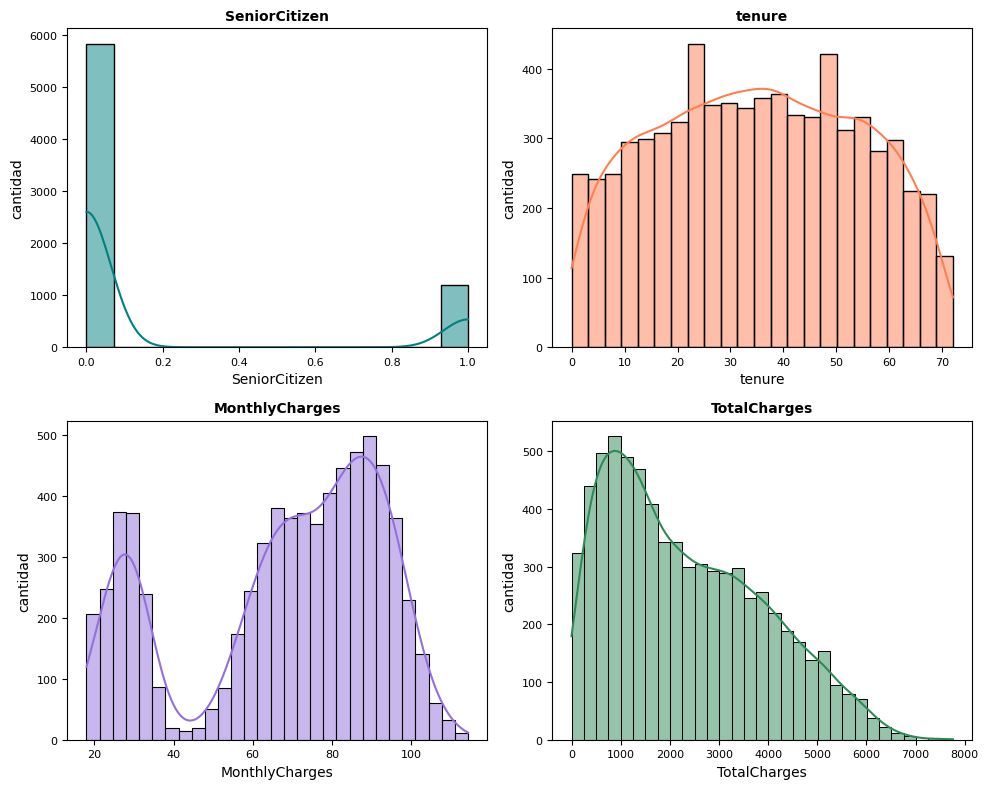

In [519]:
# Grafico de distribucion para cada variable numerica
colores_num = ["teal", "coral", "mediumpurple", "seagreen"]

n_num = len(columnas_numericas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flat

for i, colum in enumerate(columnas_numericas):
    color = colores_num[i]
    sns.histplot(
        data=df,
        x=colum,
        stat="count",
        kde=True,
        color=color,
        ax=axes[i],
    )
    axes[i].set_title(colum, fontsize=10, fontweight="bold")
    axes[i].tick_params(labelsize=8)
    axes[i].set_xlabel(colum)
    axes[i].set_ylabel("cantidad")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()


## 4. Univariado categorico y target

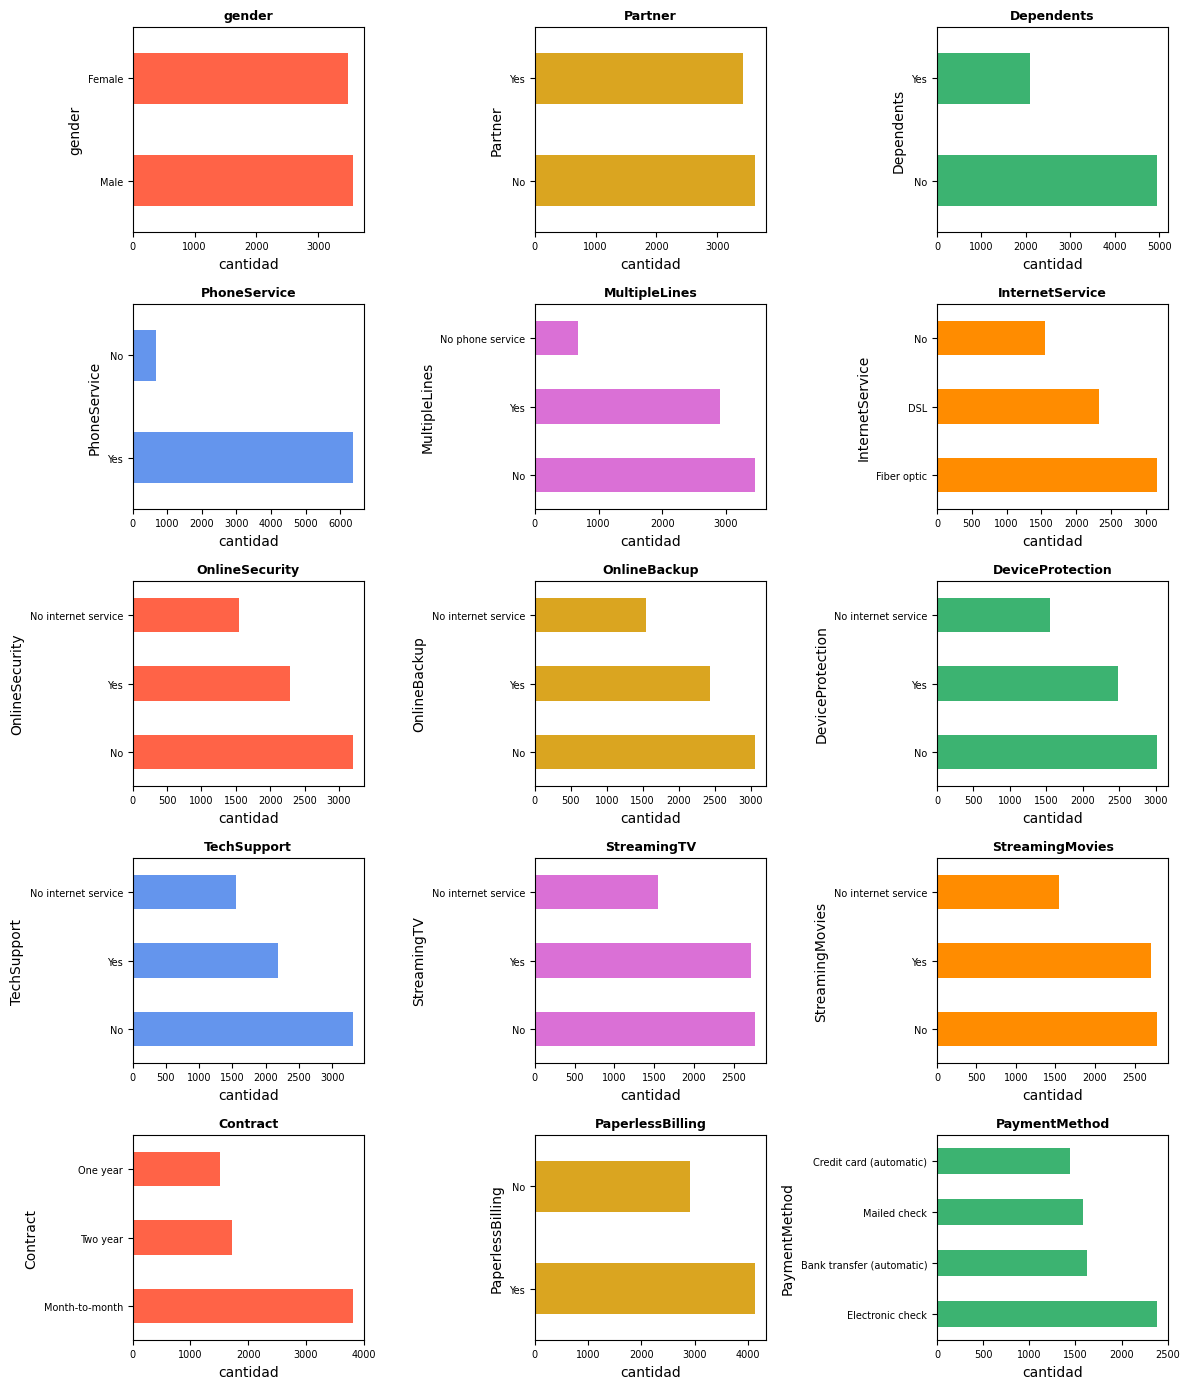

In [520]:
# Grafico de barras horizontales para cada variable categorica
colores_cat = [
    "tomato",
    "goldenrod",
    "mediumseagreen",
    "cornflowerblue",
    "orchid",
    "darkorange",
]

n_cat = len(columnas_categoricas)
n_filas = 5
n_cols = 3

fig, axes = plt.subplots(nrows=n_filas, ncols=n_cols, figsize=(12, 14))
axes = axes.flat

for i, colum in enumerate(columnas_categoricas):
    color = colores_cat[i % len(colores_cat)]
    df[colum].value_counts().plot.barh(ax=axes[i], color=color)
    axes[i].set_title(colum, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)
    axes[i].set_xlabel("cantidad")
    axes[i].set_ylabel(colum)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()


Churn
No     5186
Yes    1857
Name: count, dtype: int64

Churn
No     0.74
Yes    0.26
Name: proportion, dtype: float64


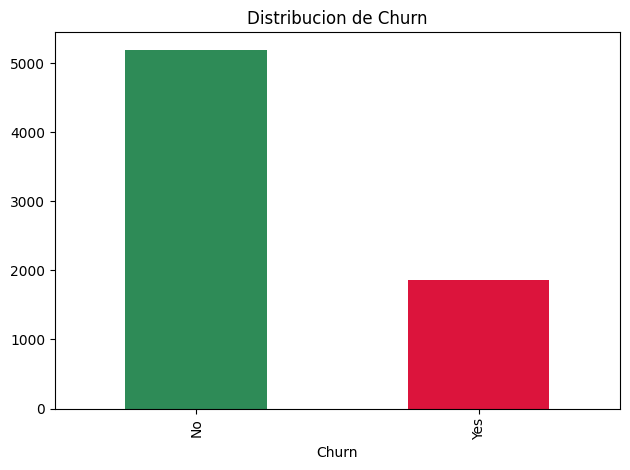

In [521]:
# Distribucion del target
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(2))

colores_churn = ["seagreen", "crimson"]

df["Churn"].value_counts().plot(
    kind="bar",
    title="Distribucion de Churn",
    color=colores_churn,
)
plt.tight_layout()
plt.show()


## 5. Outliers (metodo IQR / Tukey)

Calculamos umbrales para `tenure`, `MonthlyCharges` y `TotalCharges`.
Despues de cada calculo, un boxplot muestra los puntos fuera de los bigotes.


tenure
Q1: 20.0 Q3: 51.0 IQR: 31.0
LB: -26.5 UP: 97.5
Cantidad fuera de rango: 0


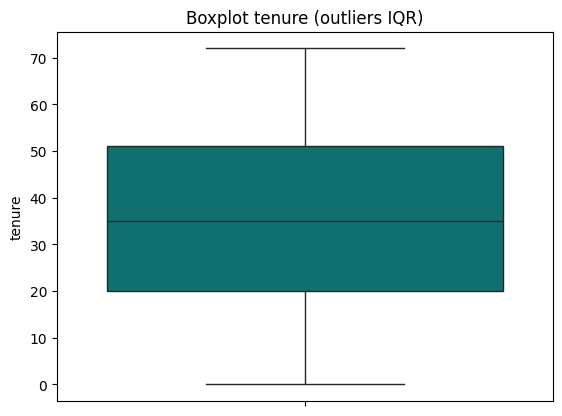

In [522]:
# Outliers de tenure
Q1 = df["tenure"].quantile(0.25)
Q3 = df["tenure"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("tenure")
print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("LB:", lower_bound, "UP:", upper_bound)

fuera_tenure = df.loc[(df["tenure"] < lower_bound) | (df["tenure"] > upper_bound)]
print("Cantidad fuera de rango:", len(fuera_tenure))

# Boxplot: puntos fuera de los bigotes = outliers
sns.boxplot(y=df["tenure"], color="teal")
plt.title("Boxplot tenure (outliers IQR)")
plt.ylabel("tenure")
plt.show()


MonthlyCharges
Q1: 55.36 Q3: 88.0 IQR: 32.64
LB: 6.399999999999999 UP: 136.96
Cantidad fuera de rango: 0


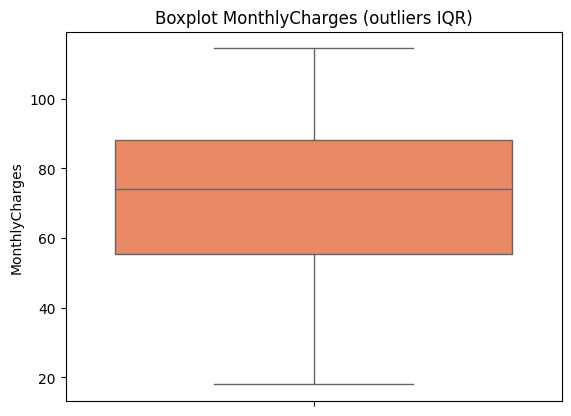

In [523]:
# Outliers de MonthlyCharges
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("MonthlyCharges")
print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("LB:", lower_bound, "UP:", upper_bound)

fuera_monthly = df.loc[(df["MonthlyCharges"] < lower_bound) | (df["MonthlyCharges"] > upper_bound)]
print("Cantidad fuera de rango:", len(fuera_monthly))

# Boxplot: puntos fuera de los bigotes = outliers
sns.boxplot(y=df["MonthlyCharges"], color="coral")
plt.title("Boxplot MonthlyCharges (outliers IQR)")
plt.ylabel("MonthlyCharges")
plt.show()


TotalCharges
Q1: 986.63 Q3: 3452.85 IQR: 2466.22
LB: -2712.7 UP: 7152.18
Cantidad fuera de rango: 4


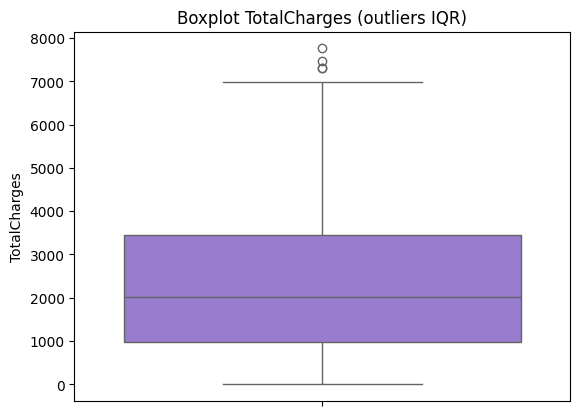

In [524]:
# Outliers de TotalCharges
Q1 = df["TotalCharges"].quantile(0.25)
Q3 = df["TotalCharges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("TotalCharges")
print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("LB:", lower_bound, "UP:", upper_bound)

fuera_total = df.loc[(df["TotalCharges"] < lower_bound) | (df["TotalCharges"] > upper_bound)]
print("Cantidad fuera de rango:", len(fuera_total))

# Boxplot: puntos fuera de los bigotes = outliers
sns.boxplot(y=df["TotalCharges"], color="mediumpurple")
plt.title("Boxplot TotalCharges (outliers IQR)")
plt.ylabel("TotalCharges")
plt.show()


## 6. Relacion con Churn

Armamos tablas de contingencia (tasa de abandono por categoria) y las
**guardamos en un diccionario** `tablas_churn`.
Despues usamos esa estructura para graficar la tasa de `Churn`.


In [525]:
# Diccionario para guardar todas las tablas vs Churn
tablas_churn = {}

In [526]:
print("Churn por Contract:")
tabla_contract = pd.crosstab(df["Contract"], df["Churn"], normalize="index")
tabla_contract = tabla_contract.round(2)

tablas_churn["Contract"] = tabla_contract
print(tablas_churn["Contract"])


Churn por Contract:
Churn             No   Yes
Contract                  
Month-to-month  0.61  0.39
One year        0.85  0.15
Two year        0.91  0.09


In [527]:
print("Churn por InternetService:")
tabla_internet = pd.crosstab(df["InternetService"], df["Churn"], normalize="index")
tabla_internet = tabla_internet.round(2)

tablas_churn["InternetService"] = tabla_internet
print(tablas_churn["InternetService"])


Churn por InternetService:
Churn              No   Yes
InternetService            
DSL              0.80  0.20
Fiber optic      0.60  0.40
No               0.92  0.08


In [528]:
print("Churn por PaymentMethod:")
tabla_pago = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")
tabla_pago = tabla_pago.round(2)

tablas_churn["PaymentMethod"] = tabla_pago
print(tablas_churn["PaymentMethod"])


Churn por PaymentMethod:
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  0.77  0.23
Credit card (automatic)    0.75  0.25
Electronic check           0.69  0.31
Mailed check               0.76  0.24


In [529]:
print("Churn por OnlineSecurity:")
tabla_seguridad = pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index")
tabla_seguridad = tabla_seguridad.round(2)

tablas_churn["OnlineSecurity"] = tabla_seguridad
print(tablas_churn["OnlineSecurity"])


Churn por OnlineSecurity:
Churn                  No   Yes
OnlineSecurity                 
No                   0.65  0.35
No internet service  0.92  0.08
Yes                  0.73  0.27


In [530]:
print("Churn por TechSupport:")
tabla_soporte = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index")
tabla_soporte = tabla_soporte.round(2)

tablas_churn["TechSupport"] = tabla_soporte
print(tablas_churn["TechSupport"])


Churn por TechSupport:
Churn                  No   Yes
TechSupport                    
No                   0.66  0.34
No internet service  0.92  0.08
Yes                  0.72  0.28


In [531]:
print("Churn por Partner:")
tabla_partner = pd.crosstab(df["Partner"], df["Churn"], normalize="index")
tabla_partner = tabla_partner.round(2)

tablas_churn["Partner"] = tabla_partner
print(tablas_churn["Partner"])

Churn por Partner:
Churn      No   Yes
Partner            
No       0.72  0.28
Yes      0.75  0.25


In [532]:
print("Tablas guardadas en tablas_churn:")
print(list(tablas_churn.keys()))

Tablas guardadas en tablas_churn:
['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'Partner']


### De las tablas guardadas al grafico

Recorremos `tablas_churn`, armamos un DataFrame y graficamos barras.


In [533]:
# Armar filas a partir del diccionario de tablas
filas = []

for nombre_var in tablas_churn:
    tabla = tablas_churn[nombre_var]
    for categoria in tabla.index:
        tasa = tabla.loc[categoria, "Yes"]
        filas.append(
            {
                "variable": nombre_var,
                "categoria": str(categoria),
                "tasa_churn": tasa,
            }
        )

df_churn_tasas = pd.DataFrame(filas)



In [534]:
df_churn_tasas

,variable,categoria,tasa_churn
0,Contract,Month-to-month,0.39
1,Contract,One year,0.15
2,Contract,Two year,0.09
3,InternetService,DSL,0.20
4,InternetService,Fiber optic,0.40
5,InternetService,No,0.08
6,PaymentMethod,Bank transfer (automatic),0.23
7,PaymentMethod,Credit card (automatic),0.25
8,PaymentMethod,Electronic check,0.31
9,PaymentMethod,Mailed check,0.24


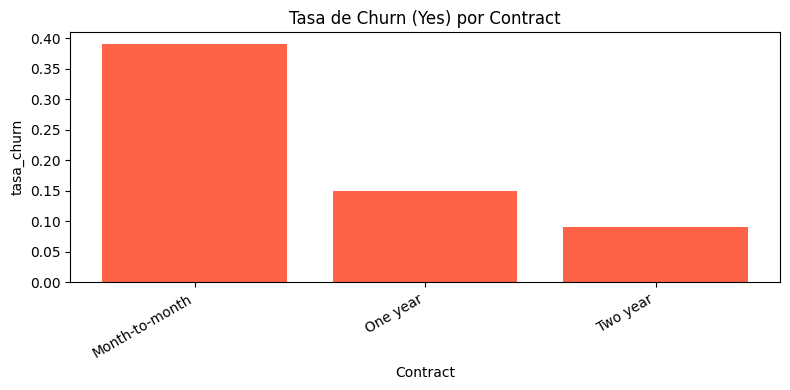

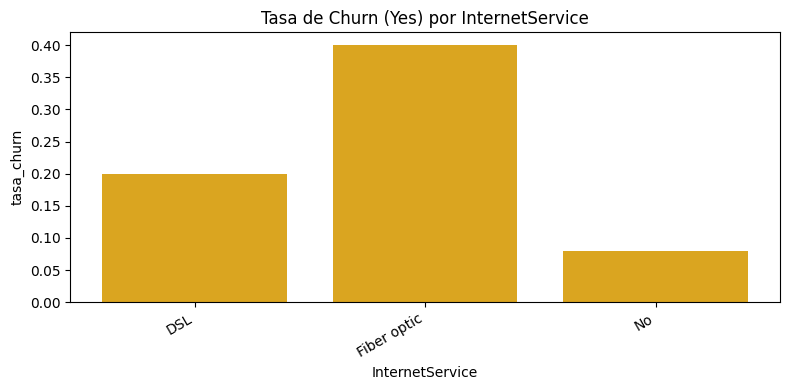

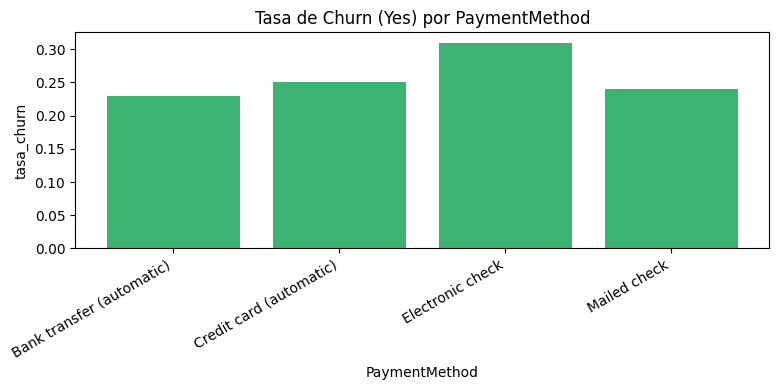

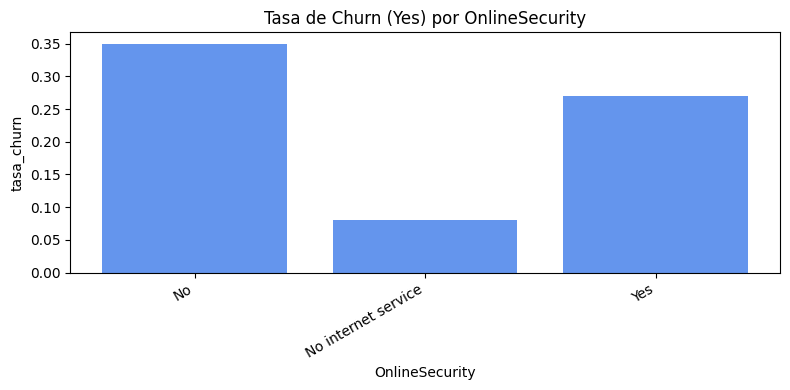

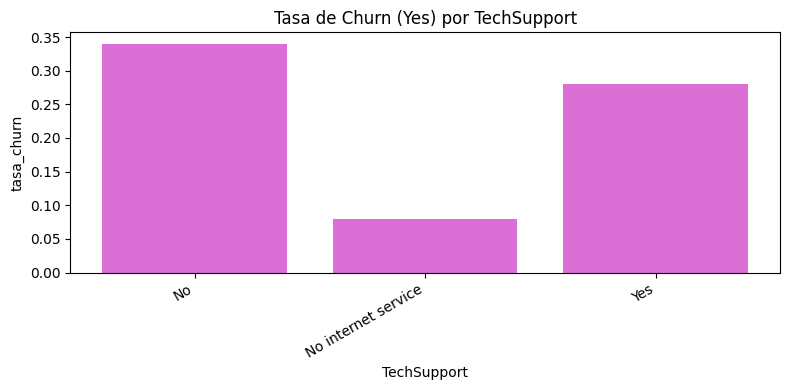

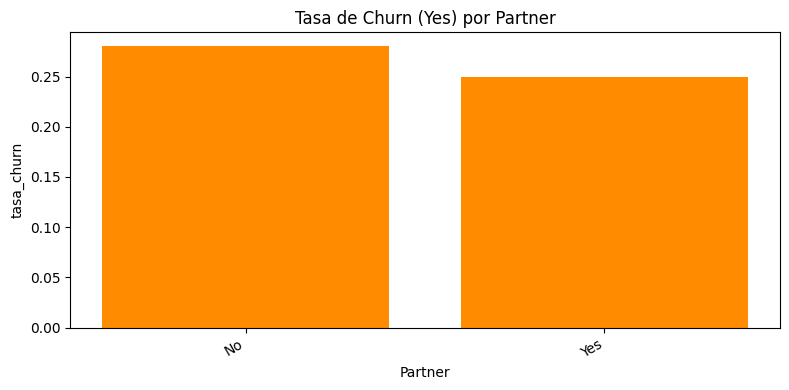

In [535]:
# Un grafico de barras por variable, usando df_churn_tasas
colores_barras = [
    "tomato",
    "goldenrod",
    "mediumseagreen",
    "cornflowerblue",
    "orchid",
    "darkorange",
]

variables = df_churn_tasas["variable"].unique()

for i, var in enumerate(variables):
    datos = df_churn_tasas.loc[df_churn_tasas["variable"] == var]
    color = colores_barras[i % len(colores_barras)]

    plt.figure(figsize=(8, 4))
    plt.bar(datos["categoria"], datos["tasa_churn"], color=color)
    plt.title("Tasa de Churn (Yes) por " + var)
    plt.ylabel("tasa_churn")
    plt.xlabel(var)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 7. Antiguedad en bins

In [536]:
df["antiguedad_bins"] = pd.cut(
    df["tenure"],
    bins=[0, 3, 12, 24, 48, 72],
    labels=["0-3", "4-12", "13-24", "25-48", "49-72"],
)

print("Churn por antiguedad_bins:")
tabla_antiguedad = pd.crosstab(df["antiguedad_bins"], df["Churn"], normalize="index")
tabla_antiguedad = tabla_antiguedad.round(3)

# Tambien la guardamos en la misma estructura
tablas_churn["antiguedad_bins"] = tabla_antiguedad
print(tablas_churn["antiguedad_bins"])


Churn por antiguedad_bins:
Churn               No    Yes
antiguedad_bins              
0-3              0.566  0.434
4-12             0.608  0.392
13-24            0.662  0.338
25-48            0.751  0.249
49-72            0.832  0.168
